# 02. Returns & Risk

Interactive exploration of portfolio return series, drawdown, VaR, and risk metrics


In [24]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

%matplotlib inline
plt.style.use("seaborn-v0_8")

In [25]:
from src.pipelines.run_pipeline import run_pipeline
out = run_pipeline(use_warehouse=False)

INFO: ============================================================
INFO: PORTFOLIO ANALYTICS PIPELINE - 2026-03-17
INFO: ============================================================
INFO: [1/10] Loading holdings...
INFO: Loading holdings from C:\Users\dipes\Desktop\Projects\portfolio-analytics-reporting\data\samples\portfolio_holdings.csv
INFO: Loaded 8 holdings rows for 8 tickers
DEBUG: Tickers: ['AAPL', 'AGG', 'GLD', 'IEFA', 'JNJ', 'MSFT', 'SPY', 'XOM']
INFO:   -> 8 rows, 8 tickers: ['AAPL', 'AGG', 'GLD', 'IEFA', 'JNJ', 'MSFT', 'SPY', 'XOM']
INFO: [2/10] Fetching prices from Yahoo Finance...
INFO: Fetching prices for 8 tickers: ['AAPL', 'AGG', 'GLD', 'IEFA', 'JNJ', 'MSFT', 'SPY', 'XOM']
INFO: Date range: 2024-01-01 to 2026-03-17
DEBUG: AAPL: 552 rows from 2024-01-02 to 2026-03-16
DEBUG: AGG: 552 rows from 2024-01-02 to 2026-03-16
DEBUG: GLD: 552 rows from 2024-01-02 to 2026-03-16
DEBUG: IEFA: 552 rows from 2024-01-02 to 2026-03-16
DEBUG: JNJ: 552 rows from 2024-01-02 to 2026-03-16
DE

In [26]:
port_returns = out['portfolio_returns']
cum_returns = out['cumulative_returns']
perf = out['perf_metrics']

print('=== Performance ===')
for k, v in perf.items():
    print(f'  {k:35s}: {v:.4f}')

=== Performance ===
  cumulative_return                  : 0.5012
  annualized_return                  : 0.2042
  annualized_volatility              : 0.1358
  sharpe_ratio                       : 1.0769
  sortino_ratio                      : 1.1437
  calmar_ratio                       : 1.3525
  hit_ratio                          : 0.5608
  best_day_return                    : 0.0875
  worst_day_return                   : -0.0486
  total_trading_days                 : 551.0000
  risk_free_rate_annual              : 0.0500


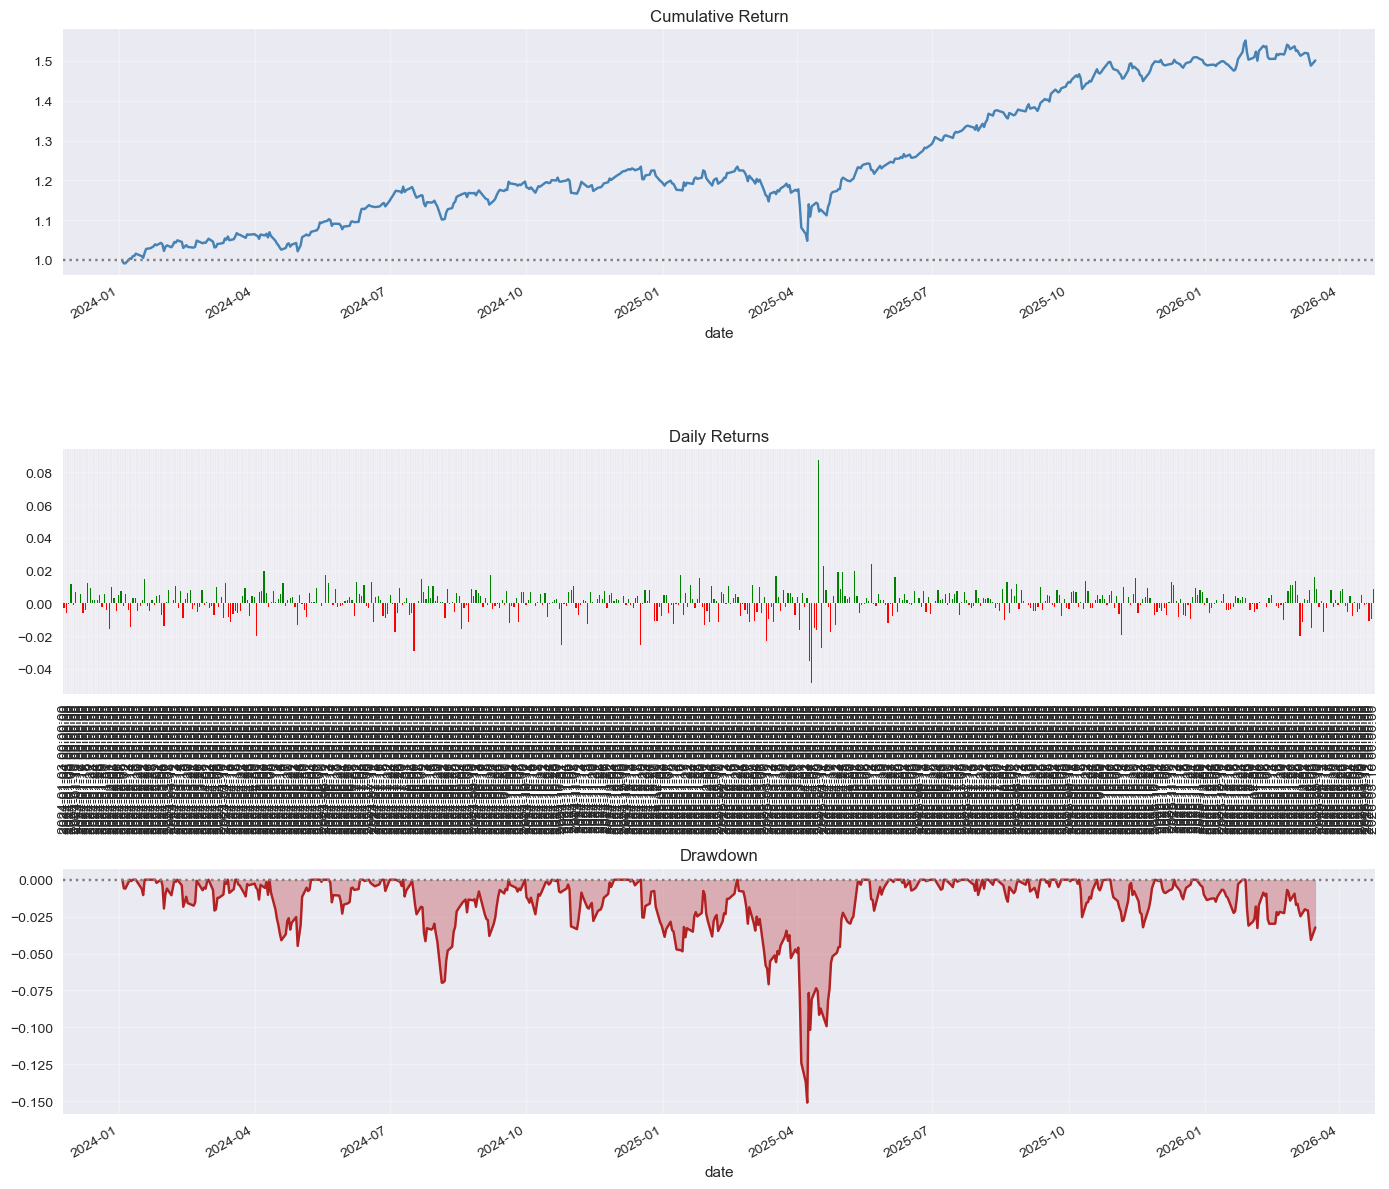

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Equity curve
(1 + port_returns).cumprod().plot(ax=axes[0], color='steelblue', title='Cumulative Return')
axes[0].axhline(1, linestyle=':', color='gray')

# Daily returns bar
port_returns.plot(ax=axes[1], kind='bar', color=['green' if r>=0 else 'red' for r in port_returns], title='Daily Returns')
axes[1].set_xlabel('')

# Drawdown
from src.analytics.risk import compute_drawdown_series
dd = compute_drawdown_series(port_returns).fillna(0)
dd.plot(ax=axes[2], color="firebrick", title="Drawdown")
axes[2].fill_between(dd.index, dd.values, 0, alpha=0.3, color="firebrick")
axes[2].axhline(0, linestyle=":", color="gray")

plt.tight_layout()
plt.show()

In [28]:
risk = out['risk_metrics']
print('=== Risk Metrics ===')
for k, v in risk.items():
    print(f'  {k:40s}: {v:.4f}')

=== Risk Metrics ===
  daily_volatility                        : 0.0086
  annualized_volatility                   : 0.1358
  downside_deviation_annual               : 0.0999
  max_drawdown                            : -0.1510
  average_drawdown                        : -0.0196
  var_95_1d                               : 0.0117
  cvar_95_1d                              : 0.0191
  return_skewness                         : 1.1405
  return_excess_kurtosis                  : 21.2286
  var_confidence                          : 0.9500


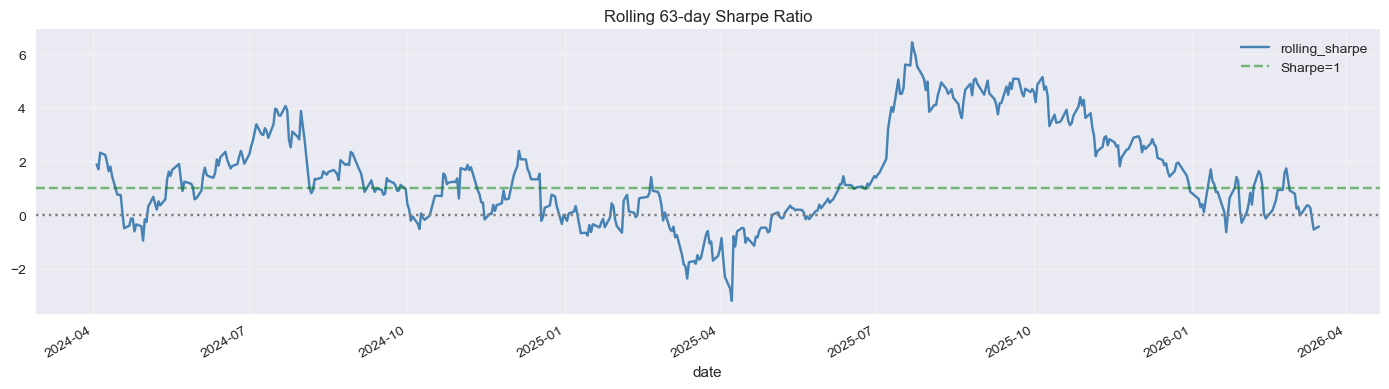

In [29]:
# Rolling Sharpe
from src.analytics.performance import compute_rolling_metrics
rolling = compute_rolling_metrics(port_returns)

fig, ax = plt.subplots(figsize=(14, 4))
rolling['rolling_sharpe'].plot(ax=ax, color='steelblue', title='Rolling 63-day Sharpe Ratio')
ax.axhline(0, linestyle=':', color='gray')
ax.axhline(1, linestyle='--', color='green', alpha=0.5, label='Sharpe=1')
ax.legend()
plt.tight_layout()
plt.show()

# 03. Factor Attribution

Deep-dive into the Fama-French 3-factor regression: betas, alpha, R², and rolling exposures.

In [30]:
factor_result = out['factor_result']
attribution = out['attribution']

print(attribution['style_summary'])
print()
for comment in attribution['commentary']:
    print('-', comment)
    print()

Defensive all-cap blend portfolio (beta=0.75, alpha=2.48%/yr, R^2=78%)

- The portfolio is moderately defensive (beta=0.75), with lower market sensitivity than the index.

- The size loading (SMB=-0.14) is near zero, indicating no strong cap bias.

- The value loading (HML=-0.05) is near neutral - the portfolio does not strongly favour either value or growth stocks.

- Alpha is not statistically significant (2.48%/yr, p=0.582). Returns are largely explained by factor exposures.

- The 3-factor model explains 78.2% of daily return variation (R^2=0.782). Some idiosyncratic return drivers are not captured by the three-factor model.



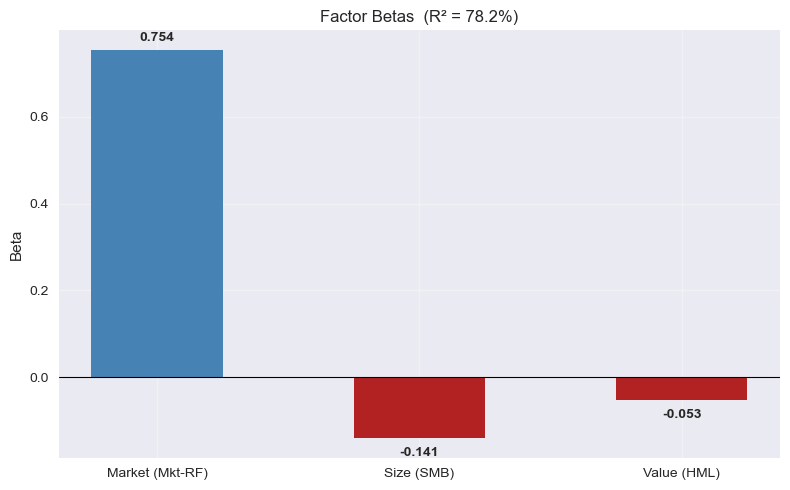

In [31]:
# Factor loadings bar chart
betas = factor_result.get_betas()
colors = ['steelblue' if v >= 0 else 'firebrick' for v in betas.values()]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(list(betas.keys()), list(betas.values()), color=colors, width=0.5)
ax.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, betas.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + (0.02 if val >= 0 else -0.04),
            f'{val:.3f}', ha='center', fontweight='bold')
ax.set_title(f'Factor Betas  (R² = {factor_result.r_squared:.1%})')
ax.set_ylabel('Beta')
plt.tight_layout()
plt.show()

In [32]:
# Full statsmodels regression summary
print(factor_result.regression_summary)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     169.0
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.40e-76
Time:                        15:22:06   Log-Likelihood:                 2135.1
No. Observations:                 521   AIC:                            -4262.
Df Residuals:                     517   BIC:                            -4245.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.704e-05      0.000      0.551      0.5

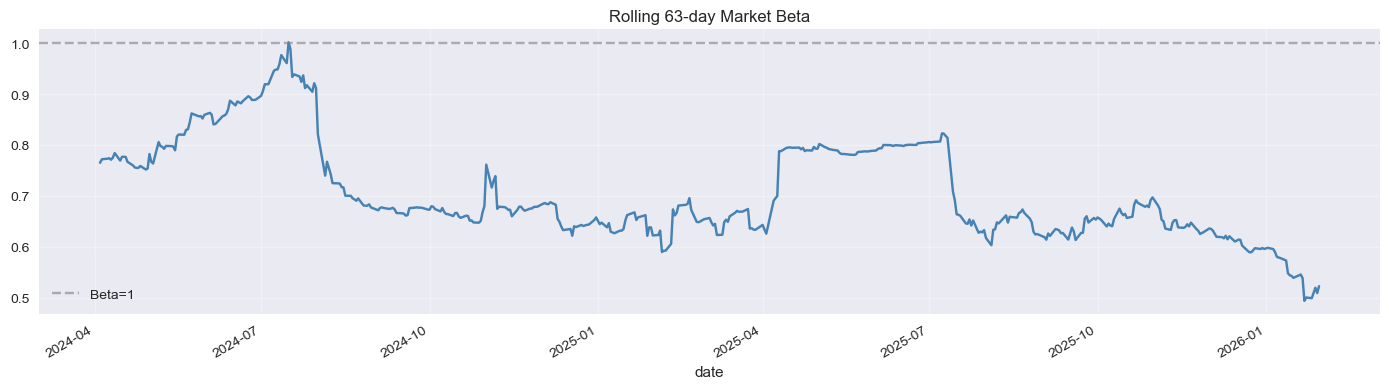

In [33]:
# Rolling 63-day market beta
port_returns = out['portfolio_returns']
factors = out['factors'].set_index('date')
factors.index = pd.to_datetime(factors.index).normalize()
port_returns.index = pd.to_datetime(port_returns.index).normalize()

common = port_returns.index.intersection(factors.index)
excess = port_returns.loc[common] - factors.loc[common, 'rf']
mkt = factors.loc[common, 'mkt_rf']

window = 63
rolling_beta = pd.Series(index=excess.index, dtype=float)

for i in range(window, len(excess)):
    y = excess.iloc[i-window:i]
    x = sm.add_constant(mkt.iloc[i-window:i])
    m = sm.OLS(y, x).fit()
    rolling_beta.iloc[i] = m.params['mkt_rf']

fig, ax = plt.subplots(figsize=(14, 4))
rolling_beta.dropna().plot(ax=ax, color='steelblue', title=f'Rolling {window}-day Market Beta')
ax.axhline(1.0, linestyle='--', color='gray', alpha=0.6, label='Beta=1')
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
# Attribution table
attribution['attribution_table']

,Factor,Loading,P-value,Significant (10%)
0,Market (Mkt-RF),0.754264,1.896333e-99,True
1,Size (SMB),-0.140821,1.033678e-07,True
2,Value (HML),-0.052816,1.150300e-01,False
3,Alpha (annual),0.024754,5.819209e-01,False
